# HDB Town Classification — Model Comparison Report

**Prepared for:** Property Agent Company  
**Dataset:** HDB Resale Flat Transactions (`data.csv`)  
**Objective:** Predict which Singapore HDB town a flat belongs to, using structural and locational features. This supports downstream applications such as neighbourhood profiling and automated listing tagging.

---

## What this notebook does

| Step | Purpose |
|------|---------|
| 1 | Define the prediction target (`town`) |
| 2 | Import libraries and load raw data |
| 3 | Inspect data quality and select relevant columns |
| 3.5 | Engineer new predictive features |
| 4 | Exploratory Data Analysis (EDA) |
| 5 | Pre-process: encode labels, split data, apply SMOTE, scale features |
| 6 | Tune Logistic Regression hyperparameter `C` via cross-validation |
| 7 | Train and evaluate final Logistic Regression |
| 8 | Define shared evaluation helper functions |
| 9–12 | Train and evaluate Random Forest, LightGBM, XGBoost, CatBoost |
| 13 | Compare all models and select the recommended production candidate |

---

## Key results (from the last run)

| Model | Test Accuracy | Runtime (s) |
|-------|--------------|-------------|
| LightGBM | **98.54%** | 59.6 |
| Random Forest | 98.99% | — |

> **Recommended model:** LightGBM — within 1% of the best test accuracy and the fastest eligible model.  
> See **Step 13** and the **Conclusion** for the full selection rationale.

---


---

## Step 1 — Define the Prediction Target

The **target variable** (also called the dependent variable or `y`) is the column we want the model to learn to predict.

In this project the target is `town` — one of 26 Singapore HDB towns such as *Ang Mo Kio*, *Tampines*, or *Jurong West*.  
Because the target is a category (not a number), this is a **multi-class classification** problem.

> **What is a target variable?**  
> Think of it as the answer we are trying to get right. All other columns in the dataset are *features* (the clues) that the model uses to predict this answer.

The numeric mapping (e.g. `ANG MO KIO → 0`) is created automatically after the data is loaded in Step 2, because the full list of towns is only known once we read the file.


In [1]:
# ── CONFIGURABLE: change this if you want to predict a different column ──
TARGET_COLUMN = 'town'   # The column the models will learn to predict

# TARGET_MAPPING is created dynamically in Step 2 once we know all unique town values.
TARGET_MAPPING = None    # Placeholder — will be populated after data load


---

## Step 2 — Import Libraries and Load the Dataset

### Libraries used

| Library | Role |
|---------|------|
| `pandas` / `numpy` | Data manipulation and numerical operations |
| `matplotlib` / `seaborn` | Visualisation |
| `scikit-learn` | Core ML utilities: splitting, scaling, Logistic Regression, Random Forest, cross-validation, metrics |
| `imbalanced-learn` (SMOTE) | Synthetic oversampling to handle class imbalance |
| `xgboost` / `lightgbm` / `catboost` | Gradient boosting libraries (optional, skipped gracefully if not installed) |

### Dataset

The dataset (`data.csv`) contains **270,619 HDB resale transactions** with 76 columns covering flat characteristics, proximity to amenities, and geolocation.  
The `town` column records which of Singapore's 26 HDB towns each flat belongs to.


In [2]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# ── Optional gradient-boosting libraries ─────────────────────────────────────
# Each is imported inside a try/except so the notebook still runs if one is
# missing. Install with: pip install xgboost lightgbm catboost
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("XGBoost not installed — Step 11 will be skipped.")

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("CatBoost not installed — Step 12 will be skipped.")

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None
    print("LightGBM not installed — Step 10 will be skipped.")

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 14
plt.style.use("fivethirtyeight")

warnings.filterwarnings('ignore')

print("All libraries imported successfully.")


All libraries imported successfully.


In [3]:
# ── CONFIGURABLE: update this list if your data file is in a different location ─
CANDIDATE_PATHS = [Path('data.csv'), Path('../data.csv')]

DATA_PATH = next((str(p) for p in CANDIDATE_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find data.csv. "
        "Place the file in the same folder as this notebook, or update CANDIDATE_PATHS above."
    )

df = pd.read_csv(DATA_PATH)

# Build the town → integer mapping from whatever towns actually exist in the data.
# Sorting ensures the mapping is deterministic across runs.
TARGET_MAPPING = {town: idx for idx, town in enumerate(sorted(df[TARGET_COLUMN].unique()))}

print(f"Dataset loaded from  : {DATA_PATH}")
print(f"Rows × Columns       : {df.shape[0]:,} × {df.shape[1]}")
print(f"Unique towns (target): {len(TARGET_MAPPING)}")
print()
df.head()


Dataset loaded from  : data.csv
Rows × Columns       : 270,619 × 76
Unique towns (target): 26



,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
2,2012-03,ANG MO KIO,4 ROOM,105,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,430000.0,...,61.0,0.0,1.369092,103.839041,398.421190,CHIJ Saint Nicholas Girls' School,256.0,1.0,1.373730,103.834309
3,2012-03,ANG MO KIO,4 ROOM,108,ANG MO KIO AVE 4,06 TO 10,92.0,New Generation,1978,427000.0,...,61.0,0.0,1.369092,103.839041,424.046635,Mayflower Secondary School,219.0,0.0,1.368337,103.835439
4,2012-03,ANG MO KIO,3 ROOM,110,ANG MO KIO AVE 4,01 TO 05,67.0,New Generation,1978,323000.0,...,61.0,0.0,1.369092,103.839041,322.732547,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3 — Inspect Data Quality and Select Feature Columns

### 3a. Dataset structure

Before modelling we check:
- **Shape** — how many rows and columns exist.
- **Data types** — are columns numeric or text?
- **Missing values** — which columns have gaps, and how many?

Missing values can cause model errors if not handled. Here we fill them with `0` for the selected columns (a safe default for count and distance features where missing usually means "none nearby").

### Why not use all 76 columns?

Using all columns would include many that are:
- **Leaky** — they directly encode the target (e.g. `planning_area` essentially *is* the town).
- **Redundant** — several distance and coordinate columns measure the same thing.
- **High-cardinality text** — raw strings like `street_name` require extra encoding and add noise.

The selected 15 core columns represent structurally distinct, meaningful signals that a model can generalise from.


In [4]:
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()

# ── Missing value summary ─────────────────────────────────────────────────────
missing_all = df.isnull().sum()
missing_nonzero = missing_all[missing_all > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing_nonzero)} out of {df.shape[1]}")
print()
print(missing_nonzero.to_string())
print()

# ── Data types ────────────────────────────────────────────────────────────────
df.info()


Dataset shape: 270,619 rows × 76 columns

Columns with missing values: 7 out of 76

Hawker_Within_500m       177013
Mall_Within_500m         168137
Hawker_Within_1km        109046
Hawker_Within_2km         52516
Mall_Within_1km           49132
Mall_Within_2km            7036
Mall_Nearest_Distance      5210

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270619 entries, 0 to 270618
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            270619 non-null  object 
 1   town                       270619 non-null  object 
 2   flat_type                  270619 non-null  object 
 3   block                      270619 non-null  object 
 4   street_name                270619 non-null  object 
 5   storey_range               270619 non-null  object 
 6   floor_area_sqm             270619 non-null  float64
 7   flat_model                 270619 non-null  object 
 8   lease

In [5]:
# Summary statistics for all numeric columns.
# Key things to look for:
#   - min/max ranges (large ranges may need scaling — handled in Step 5d)
#   - large differences between mean and 50% (median) suggest skew
#   - zero std means a column has no variation and is useless for modelling
df.describe()


,floor_area_sqm,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,floor_area_sqft,...,pri_sch_nearest_distance,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
count,270619.000000,270619.000000,2.706190e+05,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,...,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000,270619.000000
mean,96.688538,1994.860209,5.077318e+05,2019.382867,6.569993,8.540509,7.520218,9.560800,8.540509,1040.751170,...,410.333804,49.501099,0.110421,1.367462,103.839956,524.446040,119.498162,0.036088,1.367066,103.840203
std,24.158391,13.743470,1.758274e+05,3.938842,3.322633,5.753127,5.757832,5.751876,5.753127,260.039993,...,246.979262,20.722907,0.313414,0.042797,0.071881,315.536641,97.268801,0.186509,0.042629,0.071779
min,31.000000,1966.000000,1.500000e+05,2012.000000,1.000000,2.000000,1.000000,3.000000,2.000000,333.680900,...,42.554863,0.000000,0.000000,1.274962,103.687588,38.913475,5.000000,0.000000,1.276029,103.687207
25%,76.000000,1984.000000,3.800000e+05,2016.000000,4.000000,5.000000,4.000000,6.000000,5.000000,818.056400,...,232.375000,32.000000,0.000000,1.337408,103.776108,297.943031,19.000000,0.000000,1.338179,103.777148
50%,93.000000,1995.000000,4.730000e+05,2020.000000,7.000000,8.000000,7.000000,9.000000,8.000000,1001.052000,...,361.106748,48.000000,0.000000,1.365518,103.844934,459.407453,188.000000,0.000000,1.367107,103.844934
75%,112.000000,2004.000000,6.038880e+05,2023.000000,9.000000,11.000000,10.000000,12.000000,11.000000,1205.556800,...,524.571779,64.000000,0.000000,1.394958,103.898773,669.551509,211.000000,0.000000,1.396218,103.899872
max,366.700000,2022.000000,1.658888e+06,2025.000000,12.000000,50.000000,49.000000,51.000000,50.000000,3947.122130,...,3306.003143,138.000000,1.000000,1.456667,103.962919,3638.977233,260.000000,1.000000,1.453280,103.961105


### 3b. Select and clean the modelling columns

Only the 15 columns listed below are used for modelling. They were chosen because each captures a **distinct, non-leaky signal** about a flat's location:

| Column | What it represents |
|--------|--------------------|
| `max_floor_lvl` | Maximum floor level of the block — taller blocks cluster in certain towns |
| `mid_storey` | The storey band of the flat sold |
| `Hawker_Within_2km` | Number of hawker centres within 2 km — varies by town |
| `floor_area_sqm` | Flat size in square metres |
| `resale_price` | Transaction price — towns have different price profiles |
| `hdb_age` | Age of the HDB block (year of transaction minus lease commencement year) |
| `1room_sold` … `exec_sold` | Mix of flat types in the block — varies by planning era and town |
| `Mall_Within_500m` | Proximity to retail — urban vs suburban towns differ |
| `Hawker_Within_500m` | Proximity to the nearest hawker centre |
| `Tranc_Year` | Transaction year — captures temporal trends |
| `town` | **Target variable** |

Any `NaN` values in these columns are filled with `0`. For count/distance features, 0 is a valid "none present" value.


In [6]:
# ── CONFIGURABLE: add or remove columns here ─────────────────────────────────
COLUMNS_TO_USE = [
    'max_floor_lvl',
    'mid_storey',
    'Hawker_Within_2km',
    'floor_area_sqm',
    'resale_price',
    'hdb_age',
    '1room_sold',
    '2room_sold',
    '3room_sold',
    '4room_sold',
    '5room_sold',
    'exec_sold',
    'Mall_Within_500m',
    'Hawker_Within_500m',
    'Tranc_Year',
    'town',   # target — kept here for filtering; excluded from X in Step 5b
]

# ── Validate all columns exist in the loaded data ────────────────────────────
missing_required = [c for c in COLUMNS_TO_USE if c not in df.columns]
if missing_required:
    raise ValueError(f"The following required columns are missing from the dataset: {missing_required}")

# ── Report missing values BEFORE filling ─────────────────────────────────────
missing_before = df[COLUMNS_TO_USE].isna().sum().sort_values(ascending=False)
print("Missing values in selected columns (before cleanup):")
print(missing_before[missing_before > 0].to_string() or "  None")
print(f"Total missing: {int(missing_before.sum()):,}")
print()

# ── Fill missing values with 0 ───────────────────────────────────────────────
# Rationale: for count and distance features, NaN typically means "none present".
df[COLUMNS_TO_USE] = df[COLUMNS_TO_USE].fillna(0)

missing_after = df[COLUMNS_TO_USE].isna().sum().sum()
print(f"Missing values after cleanup: {missing_after}")
print(f"Rows retained: {len(df):,}  (no rows dropped — we fill, not drop)")


Missing values in selected columns (before cleanup):
Hawker_Within_500m    177013
Mall_Within_500m      168137
Hawker_Within_2km      52516
Total missing: 397,666

Missing values after cleanup: 0
Rows retained: 270,619  (no rows dropped — we fill, not drop)


---

## Step 3.5 — Feature Engineering

**Feature engineering** means creating new columns from existing ones to give the model more useful information.

> **Why engineer features?**  
> Raw columns sometimes hide useful patterns. For example, knowing that a flat is on floor 10 of a 12-floor block (83% up) is more meaningful than knowing "floor 10" in isolation. Engineered features capture these relationships explicitly.

### Features created in this step

| New feature | Formula / logic | Intuition |
|-------------|----------------|-----------|
| `distance_from_cbd` | Haversine distance from flat to CBD (Raffles Place) | Different towns are at different distances from the city centre |
| `age_location_score` | `hdb_age × (distance_from_cbd / max_distance)` | Older flats far from CBD are typically in mature estates |
| `block_total_units` | Sum of all flat types sold in the block | Block size varies by town planning era |
| `storey_ratio` | `mid_storey / max_floor_lvl` | Relative floor position within the block |
| `price_psm` | `resale_price / floor_area_sqm` | Price per square metre — normalises for flat size |
| `amenity_cluster` | Count of MRT / mall / hawker / school within close range (0–4) | Towns differ in how well-served they are by amenities |
| `block_diversity` | Shannon entropy of the flat-type mix in the block | Measures how mixed-use a block is |

> **Shannon entropy** is a measure of variety. A block with only 5-room flats has low entropy (0). A block with equal numbers of 2-, 3-, 4-, and 5-room flats has high entropy. This can signal whether a block is in a newer or older estate.


In [7]:
# ── Haversine helper — computes distance (km) between two lat/lon points ────
def haversine(lat1, lon1, lat2, lon2):
    """Return the great-circle distance in kilometres between two points."""
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

CBD_LAT, CBD_LON = 1.2897, 103.8501   # Raffles Place MRT (CBD reference point)

# Feature 1 — distance_from_cbd ───────────────────────────────────────────────
if {'Latitude', 'Longitude'}.issubset(df.columns):
    df['distance_from_cbd'] = haversine(df['Latitude'], df['Longitude'], CBD_LAT, CBD_LON)
elif {'latitude', 'longitude'}.issubset(df.columns):
    df['distance_from_cbd'] = haversine(df['latitude'], df['longitude'], CBD_LAT, CBD_LON)
else:
    df['distance_from_cbd'] = 0
    print("Warning: Latitude/Longitude not found — distance_from_cbd set to 0.")

# Feature 2 — age_location_score ──────────────────────────────────────────────
max_cbd_distance = df['distance_from_cbd'].max()
if max_cbd_distance > 0:
    df['age_location_score'] = df['hdb_age'] * (df['distance_from_cbd'] / max_cbd_distance)
else:
    df['age_location_score'] = 0

# Feature 3 — block_total_units ───────────────────────────────────────────────
unit_cols = ['1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold']
available_unit_cols = [c for c in unit_cols if c in df.columns]
df['block_total_units'] = df[available_unit_cols].sum(axis=1) if available_unit_cols else 0

# Feature 4 — storey_ratio ────────────────────────────────────────────────────
mid_storey_num = pd.to_numeric(df['mid_storey'], errors='coerce')
max_floor_safe = pd.to_numeric(df['max_floor_lvl'], errors='coerce').replace(0, np.nan)
df['storey_ratio'] = (mid_storey_num / max_floor_safe).fillna(0)

# Feature 5 — price_psm (price per square metre) ──────────────────────────────
floor_area_safe = pd.to_numeric(df['floor_area_sqm'], errors='coerce').replace(0, np.nan)
df['price_psm'] = (pd.to_numeric(df['resale_price'], errors='coerce') / floor_area_safe).fillna(0)

# Feature 6 — amenity_cluster (count of nearby amenity types) ─────────────────
df['mrt_close']    = (df['mrt_nearest_distance']  < 500 ).astype(int) if 'mrt_nearest_distance'  in df.columns else 0
df['mall_close']   = (df['Mall_Nearest_Distance']  < 1000).astype(int) if 'Mall_Nearest_Distance'  in df.columns else 0
df['hawker_close'] = (df['Hawker_Nearest_Distance'] < 500 ).astype(int) if 'Hawker_Nearest_Distance' in df.columns else 0
df['school_close'] = (df['pri_sch_nearest_distance']< 500 ).astype(int) if 'pri_sch_nearest_distance' in df.columns else 0
df['amenity_cluster'] = df['mrt_close'] + df['mall_close'] + df['hawker_close'] + df['school_close']

# Feature 7 — block_diversity (Shannon entropy of flat-type mix) ───────────────
if available_unit_cols:
    counts_df = df[available_unit_cols].fillna(0)
    totals    = counts_df.sum(axis=1).replace(0, np.nan)
    probs     = counts_df.div(totals, axis=0).replace(0, np.nan)
    df['block_diversity'] = -(probs * np.log2(probs)).sum(axis=1).fillna(0)
else:
    df['block_diversity'] = 0

# ── Summary of engineered features ───────────────────────────────────────────
new_cols = [
    'distance_from_cbd', 'age_location_score', 'block_total_units',
    'storey_ratio', 'price_psm', 'amenity_cluster', 'block_diversity'
]
print("Engineered features created:")
print(f"{'Feature':<25} {'Min':>10} {'Max':>12} {'Mean':>12}")
print("-" * 62)
for col in new_cols:
    if col in df.columns:
        print(f"{col:<25} {df[col].min():>10.2f} {df[col].max():>12.2f} {df[col].mean():>12.2f}")
print(f"\nDataset now has {df.shape[1]} columns.")


Engineered features created:
Feature                          Min          Max         Mean
--------------------------------------------------------------
distance_from_cbd               0.69        19.58        11.97
age_location_score              0.76        48.73        17.49
block_total_units               0.00       539.00       125.78
storey_ratio                    0.04         1.50         0.56
price_psm                    2207.79     16148.94      5313.80
amenity_cluster                 0.00         4.00         2.25
block_diversity                -0.00         1.88         0.67

Dataset now has 87 columns.


Transactions per town (target: town):
town
SENGKANG           20854
WOODLANDS          19845
JURONG WEST        18910
TAMPINES           18790
YISHUN             18271
PUNGGOL            16968
BEDOK              15064
HOUGANG            13815
CHOA CHU KANG      12125
ANG MO KIO         11511
BUKIT BATOK        11214
BUKIT MERAH        10390
BUKIT PANJANG       9581
TOA PAYOH           8616
KALLANG/WHAMPOA     8231
PASIR RIS           7999
SEMBAWANG           7884
QUEENSTOWN          7310
GEYLANG             6940
CLEMENTI            6249
JURONG EAST         5745
SERANGOON           5066
BISHAN              4748
CENTRAL AREA        2147
MARINE PARADE       1717
BUKIT TIMAH          629

Class imbalance ratio (largest / smallest town): 33.2x
→ This ratio explains why SMOTE is applied in Step 5d.


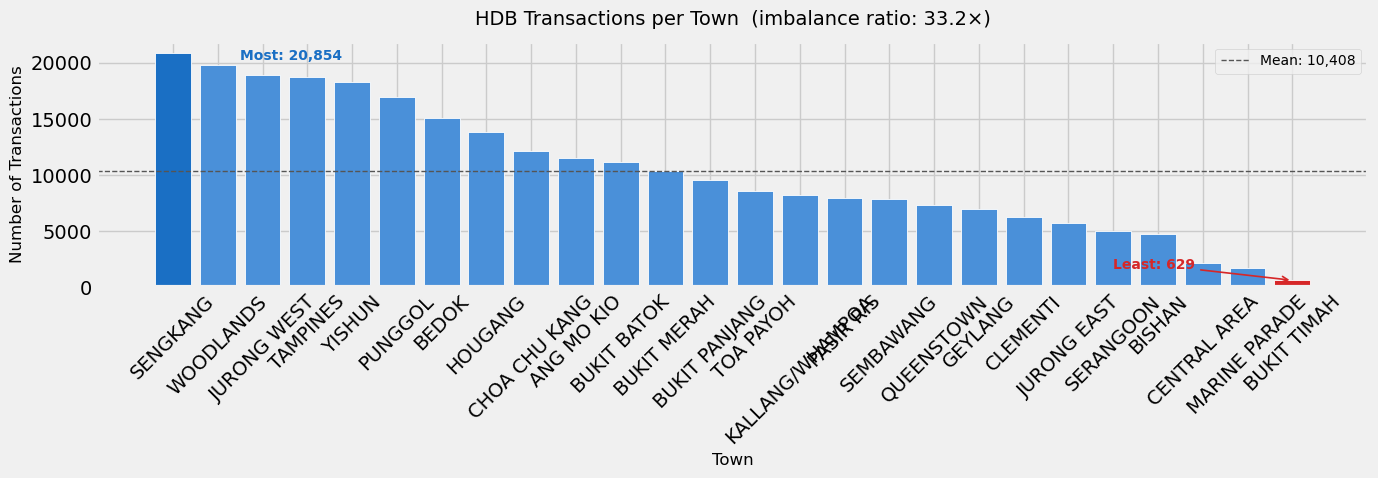

In [8]:
# ── Target class distribution ─────────────────────────────────────────────────
town_counts = df[TARGET_COLUMN].value_counts().sort_values(ascending=False)
max_count   = town_counts.max()
min_count   = town_counts.min()
imbalance_ratio = max_count / min_count

print(f"Transactions per town (target: {TARGET_COLUMN}):")
print(town_counts.to_string())
print(f"\nClass imbalance ratio (largest / smallest town): {imbalance_ratio:.1f}x")
print("→ This ratio explains why SMOTE is applied in Step 5d.")

# ── Chart: transaction count per town with imbalance annotation ───────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = ['#1a6fc4' if c == town_counts.idxmax() else
          '#d62728' if c == town_counts.idxmin() else
          '#4a90d9'
          for c in town_counts.index]

bars = ax.bar(town_counts.index, town_counts.values, color=colors, edgecolor='white', linewidth=0.6)

# Annotate min and max bars
ax.annotate(
    f'Most: {max_count:,}',
    xy=(0, max_count), xytext=(1.5, max_count * 0.97),
    fontsize=10, color='#1a6fc4', fontweight='bold'
)
ax.annotate(
    f'Least: {min_count:,}',
    xy=(len(town_counts) - 1, min_count),
    xytext=(len(town_counts) - 5, min_count + max_count * 0.05),
    fontsize=10, color='#d62728', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.2)
)

ax.axhline(town_counts.mean(), color='#555', linestyle='--', linewidth=1, label=f'Mean: {town_counts.mean():,.0f}')
ax.set_title(f'HDB Transactions per Town  (imbalance ratio: {imbalance_ratio:.1f}×)', fontsize=14, pad=12)
ax.set_xlabel('Town', fontsize=12)
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


---

## Step 4 — Exploratory Data Analysis (EDA)

EDA helps us understand **how well each feature separates the towns** before we commit to a model.

### 4a. Feature distributions by town (boxplots)

A **boxplot** shows the spread of a feature's values for each class:
- The **box** covers the middle 50% of values (25th to 75th percentile).
- The **line** inside the box is the median.
- **Whiskers** extend to ~1.5× the box range; dots beyond that are outliers.

**What to look for:**  
Features where the boxes for different towns are clearly separated (non-overlapping) are the most useful for prediction. Features where all towns look identical can usually be dropped.


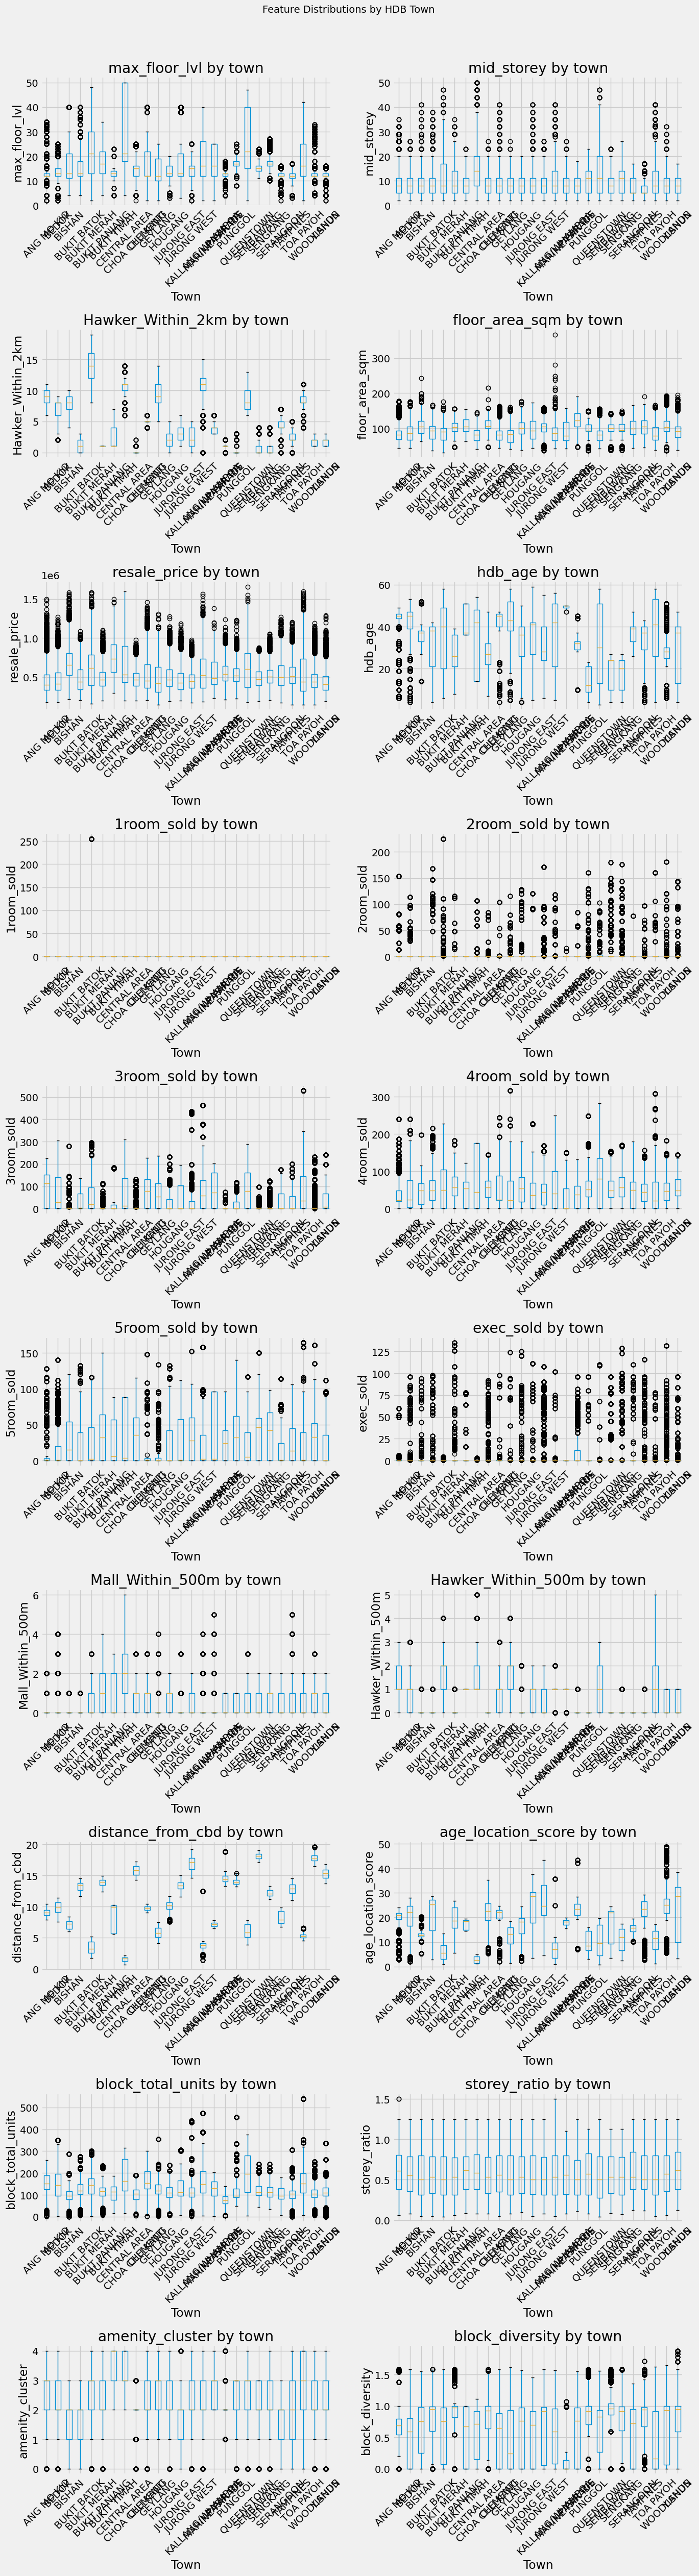

In [9]:
# ── CONFIGURABLE: update this list if you add or remove engineered features ──
FEATURES_TO_PLOT = [
    'max_floor_lvl', 'mid_storey', 'Hawker_Within_2km', 'floor_area_sqm',
    'resale_price', 'hdb_age', '1room_sold', '2room_sold', '3room_sold',
    '4room_sold', '5room_sold', 'exec_sold', 'Mall_Within_500m',
    'Hawker_Within_500m', 'distance_from_cbd', 'age_location_score',
    'block_total_units', 'storey_ratio', 'amenity_cluster', 'block_diversity'
]

n_cols   = 2
n_rows   = (len(FEATURES_TO_PLOT) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURES_TO_PLOT):
    if col in df.columns:
        df.boxplot(column=col, by=TARGET_COLUMN, ax=axes[i])
        axes[i].set_title(f'{col} by town')
        axes[i].set_xlabel('Town')
        axes[i].set_ylabel(col)
        axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplot slots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by HDB Town', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Reading the boxplots:**

- **`distance_from_cbd`** — towns are clearly separated (central towns like *Kallang* sit close to 0 km; fringe towns like *Jurong West* sit ~15 km away). This is a strong predictor.
- **`resale_price`** — prices differ by town, giving useful signal.
- **`mid_storey`** — moderate separation; some towns have taller blocks.
- **`Hawker_Within_2km`** — mature estates tend to have more hawker centres nearby.

Features with heavy overlap across all towns contribute less and may be candidates for removal in future iterations.


### 4b. Class separation summary (mean and standard deviation per town)

The table below shows the **average value** of each feature for every town. Large differences between towns confirm that the feature is discriminative.


In [10]:
# Mean feature value per town — large cross-town variation = useful feature
class_means = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].mean()
print("Mean feature values by town:")
display(class_means.round(2))


Mean feature values by town:


,max_floor_lvl,mid_storey,Hawker_Within_2km,floor_area_sqm,resale_price,hdb_age,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,Mall_Within_500m,Hawker_Within_500m,distance_from_cbd,age_location_score,block_total_units,storey_ratio,amenity_cluster,block_diversity
town,,,,,,,,,,,,,,,,,,,,
ANG MO KIO,14.82,8.25,9.16,84.10,462611.53,40.75,0.00,2.75,90.40,41.29,16.07,1.28,0.27,1.30,9.05,18.86,151.79,0.57,2.61,0.60
BEDOK,13.78,7.60,6.95,89.05,463109.46,40.17,0.00,2.38,78.01,47.02,18.01,3.38,0.38,0.96,9.78,20.10,148.80,0.56,2.25,0.48
BISHAN,15.72,8.20,7.83,106.72,678465.30,35.55,0.00,0.00,16.35,47.39,30.90,6.77,0.22,0.11,7.10,12.82,101.41,0.54,1.74,0.63
BUKIT BATOK,15.60,8.39,1.18,93.38,480337.53,29.88,0.00,6.41,36.35,58.08,22.14,5.83,0.13,0.15,13.28,20.12,128.80,0.56,1.68,0.75
BUKIT MERAH,21.40,11.28,13.92,86.35,613805.61,33.71,2.85,5.11,57.10,58.97,25.05,0.13,0.32,1.64,3.38,5.83,149.21,0.54,2.70,0.59
BUKIT PANJANG,18.06,9.73,1.00,102.73,486799.03,25.52,0.00,2.37,12.96,60.56,36.56,9.19,0.97,0.19,13.86,17.87,121.64,0.54,2.43,0.83
BUKIT TIMAH,12.95,7.50,2.21,108.78,753428.38,41.88,0.00,0.00,32.66,41.51,26.71,12.76,0.85,1.00,8.43,17.28,113.64,0.59,3.43,0.54
CENTRAL AREA,28.30,15.97,10.71,80.71,661806.48,34.99,0.00,5.23,71.47,75.85,30.35,0.09,2.03,1.75,1.59,2.73,183.00,0.59,3.33,0.57
CHOA CHU KANG,15.12,8.20,0.09,108.83,476704.54,25.33,0.00,1.17,7.32,53.05,36.49,7.10,0.97,0.00,15.82,20.47,105.13,0.55,2.02,0.73


In [11]:
# Standard deviation per town — high within-town spread can reduce separability
class_std = df.groupby(TARGET_COLUMN)[FEATURES_TO_PLOT].std()
print("Standard deviation of feature values by town:")
display(class_std.round(2))


Standard deviation of feature values by town:


,max_floor_lvl,mid_storey,Hawker_Within_2km,floor_area_sqm,resale_price,hdb_age,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,Mall_Within_500m,Hawker_Within_500m,distance_from_cbd,age_location_score,block_total_units,storey_ratio,amenity_cluster,block_diversity
town,,,,,,,,,,,,,,,,,,,,
ANG MO KIO,6.60,5.57,1.49,20.38,188158.41,11.10,0.00,14.89,71.95,42.08,32.52,4.90,0.57,0.60,0.58,5.29,44.28,0.28,0.95,0.34
BEDOK,3.88,4.43,1.77,24.35,166594.02,10.48,0.00,14.20,90.84,52.45,31.85,14.22,0.97,0.73,0.97,5.86,65.53,0.29,0.93,0.41
BISHAN,7.86,6.06,1.43,24.44,212443.72,6.26,0.00,0.00,43.45,34.98,36.11,19.68,0.41,0.31,0.69,2.34,39.43,0.29,0.91,0.40
BUKIT BATOK,7.55,5.92,1.16,24.96,167934.57,13.60,0.00,26.30,40.94,48.50,35.23,20.34,0.33,0.36,0.75,9.18,50.06,0.29,0.79,0.41
BUKIT MERAH,9.68,8.04,2.37,22.63,235741.86,16.29,26.79,22.38,74.89,57.50,33.88,0.55,0.56,0.91,0.97,3.37,57.78,0.28,1.00,0.47
BUKIT PANJANG,6.39,6.24,0.00,20.36,135469.09,9.46,0.00,13.75,26.27,40.37,36.79,23.26,1.01,0.39,0.58,6.17,42.13,0.28,0.77,0.45
BUKIT TIMAH,3.33,3.96,1.89,26.32,246408.39,6.85,0.00,0.00,66.00,40.06,29.20,27.20,1.13,0.00,2.14,2.04,45.04,0.27,0.73,0.44
CENTRAL AREA,14.88,11.27,1.76,19.12,300404.87,15.09,0.00,19.26,88.89,75.01,39.17,0.46,1.33,1.02,0.39,1.26,75.84,0.27,0.56,0.39
CHOA CHU KANG,3.59,4.68,0.28,19.26,115065.03,9.98,0.00,8.68,22.11,33.75,32.42,19.21,0.73,0.00,0.79,7.83,32.77,0.28,0.69,0.43


### 4c. Correlation matrix (multicollinearity check)

The heatmap below shows **correlations between features** (not between features and the target).

> **Why check this?**  
> Highly correlated features (|r| > 0.8) are redundant — they tell the model the same thing twice. Removing one of a correlated pair can reduce noise and training time without hurting accuracy.

This does **not** tell us which features predict the target; it only flags potential redundancy.


In [12]:
CORRELATION_THRESHOLD = 0.8

corr_matrix = df[FEATURES_TO_PLOT].corr().round(2)

# ── Style the correlation table ───────────────────────────────────────────────
# Colour-code cells: dark red = strong positive, white = none, dark blue = strong negative.
# Values on the diagonal are always 1.0 (a feature perfectly correlates with itself).
styled = (
    corr_matrix.style
    .background_gradient(cmap='RdBu_r', vmin=-1, vmax=1, axis=None)
    .format('{:.2f}')
    .set_caption('Feature Correlation Matrix — values range from -1 (inverse) to +1 (perfect positive)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'), ('padding-bottom', '8px')]},
        {'selector': 'th',
         'props': [('font-size', '11px'), ('text-align', 'center')]},
        {'selector': 'td',
         'props': [('font-size', '11px'), ('text-align', 'center'), ('width', '62px')]},
    ])
)
display(styled)

# ── Flag high-correlation pairs in plain text ─────────────────────────────────
print(f"\nFeature pairs with |r| > {CORRELATION_THRESHOLD} (consider removing one from each pair):")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > CORRELATION_THRESHOLD:
            direction = "positive" if r > 0 else "negative"
            print(f"  {corr_matrix.columns[i]:<25}  &  {corr_matrix.columns[j]:<25}  r = {r:+.2f}  ({direction})")
            found = True
if not found:
    print("  None found — all features are sufficiently independent.")


,max_floor_lvl,mid_storey,Hawker_Within_2km,floor_area_sqm,resale_price,hdb_age,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,Mall_Within_500m,Hawker_Within_500m,distance_from_cbd,age_location_score,block_total_units,storey_ratio,amenity_cluster,block_diversity
max_floor_lvl,1.00,0.57,0.24,0.03,0.47,-0.46,-0.01,0.06,-0.08,0.39,0.35,-0.06,0.03,0.13,-0.28,-0.51,0.42,-0.08,0.09,0.15
mid_storey,0.57,1.00,0.13,-0.00,0.35,-0.27,-0.01,0.04,-0.03,0.22,0.19,-0.05,0.02,0.08,-0.16,-0.31,0.24,0.70,0.05,0.09
Hawker_Within_2km,0.24,0.13,1.00,-0.27,0.15,0.35,0.05,0.02,0.35,0.02,-0.12,-0.12,-0.09,0.64,-0.81,-0.31,0.32,-0.00,0.18,-0.16
floor_area_sqm,0.03,-0.00,-0.27,1.00,0.58,-0.16,-0.06,-0.27,-0.57,-0.07,0.39,0.51,0.07,-0.28,0.26,0.11,-0.41,-0.04,-0.08,-0.07
resale_price,0.47,0.35,0.15,0.58,1.00,-0.40,-0.03,-0.09,-0.39,0.15,0.32,0.28,0.05,0.00,-0.20,-0.42,-0.08,0.04,0.08,0.04
hdb_age,-0.46,-0.27,0.35,-0.16,-0.40,1.00,0.03,-0.18,0.43,-0.31,-0.27,0.02,-0.02,0.33,-0.30,0.60,0.05,0.03,0.08,-0.39
1room_sold,-0.01,-0.01,0.05,-0.06,-0.03,0.03,1.00,-0.00,-0.01,-0.02,-0.02,-0.01,-0.01,0.01,-0.04,-0.02,0.05,-0.00,-0.01,-0.03
2room_sold,0.06,0.04,0.02,-0.27,-0.09,-0.18,-0.00,1.00,0.05,-0.10,-0.15,-0.06,-0.03,0.05,-0.01,-0.21,0.15,0.00,-0.02,0.16
3room_sold,-0.08,-0.03,0.35,-0.57,-0.39,0.43,-0.01,0.05,1.00,-0.27,-0.40,-0.16,-0.05,0.36,-0.29,0.11,0.66,0.02,0.09,-0.06
4room_sold,0.39,0.22,0.02,-0.07,0.15,-0.31,-0.02,-0.10,-0.27,1.00,-0.04,-0.29,-0.00,-0.03,-0.04,-0.22,0.33,-0.04,0.01,0.08



Feature pairs with |r| > 0.8 (consider removing one from each pair):
  Hawker_Within_2km          &  distance_from_cbd          r = -0.81  (negative)


---

## Step 5 — Model Pre-processing

Before feeding data to any model, we must:

1. **Encode the target** — convert town names (strings) to integers, because models work with numbers.
2. **Define X and y** — separate the feature matrix (X) from the target vector (y).
3. **Split** — divide data into training set (75%) and testing set (25%).
4. **Handle class imbalance** — apply SMOTE to the training set so every town has equal representation.
5. **Scale features** — use `StandardScaler` so all features are on the same numeric scale.

> **Why do all of this before modelling?**  
> Each step prevents a specific source of error or bias. Skipping any of them risks producing misleading accuracy numbers that don't hold up in production.

### 5a. Encode target labels as integers


In [13]:
# ── CONFIGURABLE: name of the new integer column ─────────────────────────────
TARGET_NUMERIC_COL = 'town_num'

# Map each town name to a unique integer (0, 1, 2, … 25)
df[TARGET_NUMERIC_COL] = df[TARGET_COLUMN].map(TARGET_MAPPING)

# Sanity check — any NaN here means a town appeared in the data but not in the mapping
unmapped = df[df[TARGET_NUMERIC_COL].isna()][TARGET_COLUMN].unique()
if len(unmapped) > 0:
    raise ValueError(
        f"The following towns were not mapped to integers: {unmapped}. "
        "This should not happen if TARGET_MAPPING was built from the same dataset."
    )

print("All towns successfully encoded as integers.")
print()
print(df[[TARGET_COLUMN, TARGET_NUMERIC_COL]].drop_duplicates().sort_values(TARGET_NUMERIC_COL).to_string(index=False))


All towns successfully encoded as integers.

           town  town_num
     ANG MO KIO         0
          BEDOK         1
         BISHAN         2
    BUKIT BATOK         3
    BUKIT MERAH         4
  BUKIT PANJANG         5
    BUKIT TIMAH         6
   CENTRAL AREA         7
  CHOA CHU KANG         8
       CLEMENTI         9
        GEYLANG        10
        HOUGANG        11
    JURONG EAST        12
    JURONG WEST        13
KALLANG/WHAMPOA        14
  MARINE PARADE        15
      PASIR RIS        16
        PUNGGOL        17
     QUEENSTOWN        18
      SEMBAWANG        19
       SENGKANG        20
      SERANGOON        21
       TAMPINES        22
      TOA PAYOH        23
      WOODLANDS        24
         YISHUN        25


### 5b. Define the feature matrix (X) and target vector (y)

We split the data into:
- **X (features)** — all input columns the model can learn from.
- **y (target)** — the integer-encoded town column the model tries to predict.

The target column and any column derived from it are **excluded from X** to prevent *target leakage* (accidentally giving the model the answer during training).

The final feature set combines:
- **Core numeric features** — the 5 most structurally meaningful raw columns.
- **Engineered features** — the 4 derived columns created in Step 3.5.


In [14]:
# ── Core raw features ────────────────────────────────────────────────────────
NUMERIC_FEATURES = [
    'max_floor_lvl',
    'Hawker_Within_2km',
    'floor_area_sqm',
    'resale_price',
    'hdb_age',
]

# ── Engineered features (only included if they were successfully created) ─────
ENGINEERED_FEATURE_CANDIDATES = [
    'block_total_units',
    'storey_ratio',
    'amenity_cluster',
    'block_diversity',
]
ENGINEERED_FEATURES = [c for c in ENGINEERED_FEATURE_CANDIDATES if c in df.columns]

FEATURE_COLUMNS = NUMERIC_FEATURES + ENGINEERED_FEATURES

# ── Validation guards ────────────────────────────────────────────────────────
missing_cols = [c for c in FEATURE_COLUMNS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Feature columns missing from dataset: {missing_cols}")

leakage_cols = [c for c in FEATURE_COLUMNS if c in {TARGET_COLUMN, TARGET_NUMERIC_COL}]
if leakage_cols:
    raise ValueError(f"Target leakage detected — remove these from FEATURE_COLUMNS: {leakage_cols}")

X = df[FEATURE_COLUMNS]
y = df[TARGET_NUMERIC_COL]

print(f"Feature matrix X  : {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"  Core features    : {NUMERIC_FEATURES}")
print(f"  Engineered       : {ENGINEERED_FEATURES}")
print(f"Target vector y   : {y.shape[0]:,} rows")
print("Target leakage guard: PASSED — no target columns present in X.")


Feature matrix X  : 270,619 rows × 9 columns
  Core features    : ['max_floor_lvl', 'Hawker_Within_2km', 'floor_area_sqm', 'resale_price', 'hdb_age']
  Engineered       : ['block_total_units', 'storey_ratio', 'amenity_cluster', 'block_diversity']
Target vector y   : 270,619 rows
Target leakage guard: PASSED — no target columns present in X.


### 5c. Train / test split

We randomly divide the data into:
- **Training set (75%)** — used to teach the model.
- **Testing set (25%)** — held back entirely; used only to evaluate the final model.

`stratify=y` ensures both sets have the **same proportion of each town**, preventing a split where, say, all *Punggol* records end up in training and none in testing.

> **Why hold back a test set?**  
> If we evaluated accuracy on the same data we trained on, the model would look perfect (it has already memorised those answers). The test set simulates brand-new, unseen transactions.


In [15]:
# ── CONFIGURABLE ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42    # Seed for reproducibility — same seed = same split every run
TEST_SIZE    = 0.25  # Fraction of data reserved for testing (25%)
# ─────────────────────────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y         # Preserve class proportions in both splits
)

# Reset index so subsequent operations (SMOTE, etc.) have clean 0-based indices
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Training set : {X_train.shape[0]:,} rows  ({1 - TEST_SIZE:.0%} of data)")
print(f"Testing set  : {X_test.shape[0]:,} rows  ({TEST_SIZE:.0%} of data)")
print(f"Unique towns in train: {y_train.nunique()} | test: {y_test.nunique()}")
print("Stratified split: PASSED — class proportions preserved in both sets.")


Training set : 202,964 rows  (75% of data)
Testing set  : 67,655 rows  (25% of data)
Unique towns in train: 26 | test: 26
Stratified split: PASSED — class proportions preserved in both sets.


### 5d. Handle class imbalance (SMOTE) and scale features

#### Why SMOTE?

Some towns have far fewer transactions than others (e.g. *Lim Chu Kang* vs *Tampines*). A model trained on imbalanced data tends to:
- Predict common towns very accurately.
- Perform poorly on rare towns, which are often the ones that need correct identification.

**SMOTE (Synthetic Minority Over-sampling Technique)** generates *synthetic* new training examples for under-represented towns by interpolating between real examples — without duplicating exact rows.

> **Important:** SMOTE is applied to the **training set only**. The test set remains the original, unmodified data. Applying SMOTE to the test set would give an artificially optimistic accuracy that wouldn't reflect real-world performance.

#### Why StandardScaler?

Many models (especially distance-based ones) are sensitive to the *magnitude* of feature values. `resale_price` can be in the hundreds of thousands, while `storey_ratio` is between 0 and 1. Without scaling, `resale_price` would dominate any distance calculation.

`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**, putting all features on a level playing field.

> The scaler is **fit on training data only**, then *applied* to both train and test. Fitting on the full dataset would leak test-set statistics into training.


In [16]:
# Snapshot the clean split — we restore from this if re-running cells
_X_train_base, _y_train_base = X_train.copy(), y_train.copy()
_X_test_base,  _y_test_base  = X_test.copy(),  y_test.copy()

# Always restore from the clean base to avoid cumulative SMOTE distortion
X_train, y_train = _X_train_base.copy(), _y_train_base.copy()
X_test,  y_test  = _X_test_base.copy(),  _y_test_base.copy()

# ── Step 1: Apply SMOTE to training data only ─────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = smote.fit_resample(X_train, y_train)
print(f"SMOTE applied — training rows: {X_train.shape[0]:,} (was {len(_X_train_base):,})")
print(f"Training class distribution after SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
print()

# ── Step 2: Create XGBoost-safe labels (consecutive integers from 0) ─────────
# XGBoost requires class labels to be exactly 0, 1, 2, … N-1.
# The original numeric encoding already satisfies this, but we re-encode
# defensively to handle any edge cases after SMOTE.
xgb_label_encoder = LabelEncoder()
y_train_xgb = xgb_label_encoder.fit_transform(y_train)
y_test_xgb  = xgb_label_encoder.transform(y_test)

missing_test_classes = set(np.unique(y_test)) - set(xgb_label_encoder.classes_)
if missing_test_classes:
    raise ValueError(f"XGBoost label issue: classes in test but not in train: {sorted(missing_test_classes)}")
print("XGBoost label mapping: PASSED")

# ── Step 3: Fit scaler on training data, transform both sets ─────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only on test

print()
print(f"Train after SMOTE + scaling : {X_train_scaled.shape[0]:,} rows × {X_train_scaled.shape[1]} features")
print(f"Test (unchanged)            : {X_test_scaled.shape[0]:,} rows × {X_test_scaled.shape[1]} features")
print("Leakage guard: scaler fit on training data only — PASSED.")


SMOTE applied — training rows: 406,640 (was 202,964)
Training class distribution after SMOTE: {0: 15640, 25: 15640, 17: 15640, 1: 15640, 8: 15640, 12: 15640, 24: 15640, 14: 15640, 3: 15640, 4: 15640, 5: 15640, 22: 15640, 13: 15640, 18: 15640, 11: 15640, 20: 15640, 10: 15640, 2: 15640, 7: 15640, 23: 15640, 15: 15640, 21: 15640, 9: 15640, 16: 15640, 19: 15640, 6: 15640}

XGBoost label mapping: PASSED

Train after SMOTE + scaling : 406,640 rows × 9 features
Test (unchanged)            : 67,655 rows × 9 features
Leakage guard: scaler fit on training data only — PASSED.


---

## Step 6 — Tune Logistic Regression Hyperparameter C

**Logistic Regression** is our baseline model. Despite the name, it performs *classification* — it learns a boundary between classes based on weighted feature combinations.

### What is the `C` parameter?

`C` controls **regularisation strength**:
- **Low C** (e.g. 0.01) — strong regularisation; the model is penalised for large coefficients, which prevents overfitting but may underfit.
- **High C** (e.g. 100) — weak regularisation; the model can fit the training data more closely, but risks overfitting.

We use **5-fold cross-validation** to find the best `C` without using the test set.

> **Cross-validation (k-fold):** The training data is divided into 5 equal "folds". The model trains on 4 folds and is evaluated on the 5th, rotating through all combinations. This gives a reliable estimate of how the model generalises, using only training data.


In [17]:
# ── CONFIGURABLE ────────────────────────────────────────────────────────────
C_VALUES = [0.01, 0.1, 1, 10, 100]   # Candidate regularisation values to test
CV_FOLDS = 5                           # Number of cross-validation folds
# ─────────────────────────────────────────────────────────────────────────────

lr_search = LogisticRegression(
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

search = GridSearchCV(
    estimator=lr_search,
    param_grid={'C': C_VALUES},
    scoring='accuracy',
    cv=cv,
    n_jobs=-1   # Use all CPU cores for speed
)

print(f"Running {CV_FOLDS}-fold cross-validation over C values: {C_VALUES} ...")
search_start = time.perf_counter()
search.fit(X_train_scaled, y_train)
search_runtime = time.perf_counter() - search_start

cv_results = (
    pd.DataFrame(search.cv_results_)[['param_C', 'mean_test_score', 'std_test_score']]
    .rename(columns={'param_C': 'C', 'mean_test_score': 'CV Accuracy', 'std_test_score': 'CV Std Dev'})
    .sort_values('CV Accuracy', ascending=False)
    .reset_index(drop=True)
)

best_C = search.best_params_['C']
print(f"\nCV search completed in {search_runtime:.1f}s")
print(f"Best C: {best_C}  (highest mean cross-validation accuracy)")
print()
display(cv_results.style.format({'CV Accuracy': '{:.4f}', 'CV Std Dev': '{:.4f}'}).hide(axis='index'))


Running 5-fold cross-validation over C values: [0.01, 0.1, 1, 10, 100] ...

CV search completed in 253.4s
Best C: 100  (highest mean cross-validation accuracy)



C,CV Accuracy,CV Std Dev
100.000000,0.4780,0.0018
10.000000,0.4779,0.0019
1.000000,0.4775,0.0019
0.100000,0.4753,0.0018
0.010000,0.4618,0.0025


### Logistic Regression tuning summary

The table above shows the average accuracy for each `C` value across the 5 CV folds. The `C` with the highest mean accuracy is selected and used to train the final Logistic Regression in Step 7.

> **CV Std Dev** measures how consistent the accuracy is across folds. A large standard deviation means the model's accuracy varies a lot depending on which data it sees — a warning sign of instability.


In [18]:
print(f"Selected C = {best_C}")
print("Logistic Regression tuning complete. Proceeding to final training in Step 7.")


Selected C = 100
Logistic Regression tuning complete. Proceeding to final training in Step 7.


---

## Step 7 — Train and Evaluate Final Logistic Regression

Using the best `C` found in Step 6, we now train the **final Logistic Regression** on the full training set and evaluate it on the held-out test set.

### Metrics explained

| Metric | What it means |
|--------|--------------|
| **Train Accuracy** | % of training examples correctly classified — tells us whether the model learned the data |
| **Test Accuracy** | % of test examples correctly classified — the honest performance estimate on unseen data |
| **Generalization Gap** | Train − Test accuracy. A large gap (> 5%) suggests the model overfitted to training data |
| **Feature Importance** | Which features most influenced predictions (from absolute coefficient magnitudes) |

The Logistic Regression serves as a **baseline** — we expect tree-based models to outperform it on this non-linear problem.


In [19]:
lr_final = LogisticRegression(
    C=best_C,
    max_iter=3000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=RANDOM_STATE
)

lr_start = time.perf_counter()
lr_final.fit(X_train_scaled, y_train)
lr_runtime = time.perf_counter() - lr_start

lr_train_acc = lr_final.score(X_train_scaled, y_train)
lr_test_acc  = lr_final.score(X_test_scaled,  y_test)

print("─" * 50)
print("Logistic Regression — Final Results")
print("─" * 50)
print(f"  Train Accuracy     : {lr_train_acc:.4f}  ({lr_train_acc*100:.2f}%)")
print(f"  Test Accuracy      : {lr_test_acc:.4f}  ({lr_test_acc*100:.2f}%)")
print(f"  Generalization Gap : {lr_train_acc - lr_test_acc:.4f}")
print(f"  Runtime            : {lr_runtime:.3f}s")
print("─" * 50)


──────────────────────────────────────────────────
Logistic Regression — Final Results
──────────────────────────────────────────────────
  Train Accuracy     : 0.4781  (47.81%)
  Test Accuracy      : 0.3826  (38.26%)
  Generalization Gap : 0.0955
  Runtime            : 37.053s
──────────────────────────────────────────────────


### Logistic Regression — Feature Importance

For Logistic Regression, "feature importance" is derived from the **model coefficients**. A larger absolute coefficient means the feature has a stronger influence on the predicted class.

Because this is a multiclass problem (26 towns), there is one coefficient per feature per class. We take the **mean absolute value across all classes** as a summary importance score.


In [20]:
# Mean absolute coefficient across all 26 town classes
lr_importance = pd.DataFrame({
    'Feature'   : FEATURE_COLUMNS,
    'Importance': np.mean(np.abs(lr_final.coef_), axis=0)
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 10 most influential features (Logistic Regression):")
display(
    lr_importance.head(10)
    .style
    .format({'Importance': '{:.6f}'})
    .hide(axis='index')
    .set_properties(subset=['Feature'], **{'text-align': 'left'})
    .set_properties(subset=['Importance'], **{'text-align': 'right'})
)


Top 10 most influential features (Logistic Regression):


Feature,Importance
Hawker_Within_2km,9.773864
hdb_age,2.509334
resale_price,2.156402
floor_area_sqm,1.554873
max_floor_lvl,1.137922
block_total_units,0.558023
amenity_cluster,0.488343
block_diversity,0.277954
storey_ratio,0.153875


---

## Step 8 — Shared Evaluation Helper Functions

The next four steps (9–12) each train a different model and evaluate it the same way. Rather than repeating code, we define three reusable helper functions here:

| Function | Purpose |
|----------|---------|
| `extract_feature_importance` | Extracts feature importance from any trained model (supports both coefficient-based and tree-based models) |
| `display_aligned_table` | Pretty-prints a DataFrame with left/right alignment and number formatting |
| `evaluate_classification_model` | Trains a model, measures train/test accuracy and runtime, returns a results dictionary |
| `print_model_result_summary` | Prints a one-line summary of a model's performance |

> **Why functions?** If we ever change how we measure accuracy or display results, we only need to update it in one place rather than in four separate blocks of code.


In [21]:
def extract_feature_importance(model, feature_columns):
    """
    Return a DataFrame of feature importances for any sklearn-compatible model.
    - Tree-based models (RF, XGB, LGBM, CatBoost): uses model.feature_importances_
    - Linear models (Logistic Regression): uses mean(|coef_|) across classes
    - Models without importance support: returns an empty DataFrame
    """
    if hasattr(model, 'feature_importances_'):
        values = model.feature_importances_
    elif hasattr(model, 'coef_'):
        coef = model.coef_
        values = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef).ravel()
    else:
        return pd.DataFrame(columns=['Feature', 'Importance'])

    return (
        pd.DataFrame({'Feature': feature_columns, 'Importance': values})
        .sort_values('Importance', ascending=False)
        .reset_index(drop=True)
    )


def display_aligned_table(df_in, format_map=None, left_cols=None, right_cols=None, hide_index=True):
    """
    Display a styled DataFrame table in Jupyter.
    Falls back to plain text printing if styling fails.
    """
    format_map = format_map or {}
    left_cols  = left_cols  or []
    right_cols = right_cols or []
    try:
        style = df_in.style
        if hide_index:
            style = style.hide(axis='index')
        if format_map:
            style = style.format(format_map)
        if left_cols:
            style = style.set_properties(subset=left_cols,  **{'text-align': 'left'})
        if right_cols:
            style = style.set_properties(subset=right_cols, **{'text-align': 'right'})
        display(style)
    except Exception:
        fallback = df_in.copy()
        for col, fmt in format_map.items():
            if col in fallback.columns:
                fallback[col] = fallback[col].map(lambda x: fmt.format(x))
        print(fallback.to_string(index=not hide_index))


def evaluate_classification_model(model, X_train_data, X_test_data,
                                   y_train_data, y_test_data,
                                   model_name, feature_columns):
    """
    Train a model, evaluate it, and return a results dictionary.

    Returns
    -------
    dict with keys: Model, Train Accuracy, Test Accuracy, Runtime (sec),
                    Feature Importance, fitted_model
    """
    start = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    runtime = time.perf_counter() - start

    train_pred = np.array(model.predict(X_train_data)).astype(int).ravel()
    test_pred  = np.array(model.predict(X_test_data)).astype(int).ravel()

    return {
        'Model'            : model_name,
        'Train Accuracy'   : accuracy_score(y_train_data, train_pred),
        'Test Accuracy'    : accuracy_score(y_test_data,  test_pred),
        'Runtime (sec)'    : runtime,
        'Feature Importance': extract_feature_importance(model, feature_columns),
        'fitted_model'     : model,
    }


def print_model_result_summary(model_name, train_acc, test_acc, runtime_sec):
    """Print a one-line performance summary for a model."""
    print(
        f"Result summary: {model_name} — "
        f"train {train_acc:.4f} | test {test_acc:.4f} | "
        f"gap {train_acc - test_acc:+.4f} | runtime {runtime_sec:.1f}s"
    )


print("Helper functions defined: extract_feature_importance, display_aligned_table,")
print("  evaluate_classification_model, print_model_result_summary")


Helper functions defined: extract_feature_importance, display_aligned_table,
  evaluate_classification_model, print_model_result_summary


In [22]:
# Shared class name list — maps integer index back to town name
# Used in confusion matrices and classification reports
class_names = [label for label, _ in sorted(TARGET_MAPPING.items(), key=lambda x: x[1])]

print(f"Shared inputs prepared for Steps 9–12:")
print(f"  Training samples : {len(X_train):,}")
print(f"  Test samples     : {len(X_test):,}")
print(f"  Towns (classes)  : {len(class_names)}")
print(f"  Features used    : {FEATURE_COLUMNS}")


Shared inputs prepared for Steps 9–12:
  Training samples : 406,640
  Test samples     : 67,655
  Towns (classes)  : 26
  Features used    : ['max_floor_lvl', 'Hawker_Within_2km', 'floor_area_sqm', 'resale_price', 'hdb_age', 'block_total_units', 'storey_ratio', 'amenity_cluster', 'block_diversity']


---

## Step 9a — Common Hyperparameter: Number of Trees (`N_ESTIMATORS`)

All three tree-based ensemble models (Random Forest, LightGBM, XGBoost) share the concept of **building many decision trees and combining their predictions**.

`N_ESTIMATORS` controls how many trees are built:
- **More trees** → generally better accuracy, but slower to train.
- **Diminishing returns** — accuracy improvement flattens after a certain point.
- **300** is a reliable starting point for this dataset size.

> Change this value here and all three models will use the same setting, making comparisons fair.


In [23]:
# ── CONFIGURABLE: shared tree count for RF, LightGBM, and XGBoost ────────────
N_ESTIMATORS = 300
# ─────────────────────────────────────────────────────────────────────────────
print(f"N_ESTIMATORS set to {N_ESTIMATORS}. This will be used by Random Forest, LightGBM, and XGBoost.")


N_ESTIMATORS set to 300. This will be used by Random Forest, LightGBM, and XGBoost.


---

## Step 9b — Random Forest

**Random Forest** builds many decision trees independently and combines their predictions by majority vote.

Key properties:
- Each tree is trained on a **random bootstrap sample** of the training data.
- At each split, only a **random subset of features** is considered — this forces diversity between trees.
- `class_weight='balanced_subsample'` adjusts for the remaining class imbalance after SMOTE by giving rarer towns more influence.

> **Why Random Forest?**  
> It is robust to outliers, handles non-linear relationships, and naturally provides feature importance. It is a strong all-round baseline that is hard to beat without careful tuning.


In [24]:
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight='balanced_subsample',   # Compensate for any remaining imbalance
    n_jobs=-1                            # Use all CPU cores
)

rf_results = evaluate_classification_model(
    rf_model, X_train_scaled, X_test_scaled, y_train, y_test,
    'Random Forest', FEATURE_COLUMNS
)

print("─" * 50)
print("Random Forest — Results")
print("─" * 50)
print(f"  Train Accuracy : {rf_results['Train Accuracy']:.4f}")
print(f"  Test Accuracy  : {rf_results['Test Accuracy']:.4f}")
print(f"  Runtime        : {rf_results['Runtime (sec)']:.1f}s")
print("─" * 50)
print_model_result_summary("Random Forest", rf_results['Train Accuracy'], rf_results['Test Accuracy'], rf_results['Runtime (sec)'])


──────────────────────────────────────────────────
Random Forest — Results
──────────────────────────────────────────────────
  Train Accuracy : 0.9997
  Test Accuracy  : 0.9899
  Runtime        : 64.4s
──────────────────────────────────────────────────
Result summary: Random Forest — train 0.9997 | test 0.9899 | gap +0.0098 | runtime 64.4s


In [25]:
print("Top 10 features — Random Forest:")
display_aligned_table(
    rf_results['Feature Importance'].head(10),
    format_map={'Importance': '{:.6f}'},
    left_cols=['Feature'], right_cols=['Importance']
)


Top 10 features — Random Forest:


Feature,Importance
Hawker_Within_2km,0.244528
hdb_age,0.207511
max_floor_lvl,0.141781
block_total_units,0.114700
block_diversity,0.087219
floor_area_sqm,0.077989
amenity_cluster,0.063805
resale_price,0.051313
storey_ratio,0.011154


---

## Step 10 — LightGBM

**LightGBM** (Light Gradient Boosting Machine) is a high-performance boosting library developed by Microsoft.

Unlike Random Forest (which trains trees in parallel and averages them), **gradient boosting trains trees sequentially** — each new tree tries to correct the mistakes of the previous ones.

Key settings used here:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `n_estimators` | 300 | Number of sequential trees |
| `learning_rate` | 0.05 | How much each tree corrects the previous — lower = more conservative, needs more trees |
| `num_leaves` | 31 | Maximum leaves per tree — controls model complexity |

> **Why LightGBM?** It is typically the fastest gradient booster for tabular data at this scale, and often achieves state-of-the-art accuracy.


In [26]:
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        num_leaves=31,
        random_state=RANDOM_STATE
    )
    lgbm_results = evaluate_classification_model(
        lgbm_model, X_train_scaled, X_test_scaled, y_train, y_test,
        'LightGBM', FEATURE_COLUMNS
    )
    print("─" * 50)
    print("LightGBM — Results")
    print("─" * 50)
    print(f"  Train Accuracy : {lgbm_results['Train Accuracy']:.4f}")
    print(f"  Test Accuracy  : {lgbm_results['Test Accuracy']:.4f}")
    print(f"  Runtime        : {lgbm_results['Runtime (sec)']:.1f}s")
    print("─" * 50)
    print_model_result_summary("LightGBM", lgbm_results['Train Accuracy'], lgbm_results['Test Accuracy'], lgbm_results['Runtime (sec)'])
else:
    print("LightGBM not installed. Install with: pip install lightgbm")
    lgbm_results = None


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003809 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1847
[LightGBM] [Info] Number of data points in the train set: 406640, number of used features: 9
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097

In [27]:
if lgbm_results is not None:
    print("Top 10 features — LightGBM:")
    display_aligned_table(
        lgbm_results['Feature Importance'].head(10),
        format_map={'Importance': '{:.6f}'},
        left_cols=['Feature'], right_cols=['Importance']
    )


Top 10 features — LightGBM:


Feature,Importance
block_total_units,39165.000000
hdb_age,36334.000000
max_floor_lvl,33307.000000
block_diversity,30291.000000
Hawker_Within_2km,29631.000000
floor_area_sqm,27829.000000
resale_price,18340.000000
amenity_cluster,13030.000000
storey_ratio,6073.000000


---

## Step 11 — XGBoost

**XGBoost** (eXtreme Gradient Boosting) is another sequential tree-boosting library, known for winning many machine learning competitions.

Additional settings compared to LightGBM:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `max_depth` | 6 | Maximum depth of each tree — limits overfitting |
| `subsample` | 0.9 | 90% of training rows sampled per tree — adds randomness, reduces overfitting |
| `colsample_bytree` | 0.9 | 90% of features sampled per tree — same idea |
| `objective` | `multi:softmax` | Multi-class classification mode |

> **XGBoost requires class labels to be consecutive integers starting at 0.** The `xgb_label_encoder` created in Step 5d handles this — `y_train_xgb` and `y_test_xgb` are used instead of `y_train` and `y_test`.


In [28]:
if XGBClassifier is not None:
    xgb_model = XGBClassifier(
        n_estimators=N_ESTIMATORS,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='multi:softmax',
        num_class=len(xgb_label_encoder.classes_),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric='mlogloss',
        verbosity=0
    )
    # Note: XGBoost uses xgb-specific label-encoded targets
    xgb_results = evaluate_classification_model(
        xgb_model, X_train_scaled, X_test_scaled, y_train_xgb, y_test_xgb,
        'XGBoost', FEATURE_COLUMNS
    )
    print("─" * 50)
    print("XGBoost — Results")
    print("─" * 50)
    print(f"  Train Accuracy : {xgb_results['Train Accuracy']:.4f}")
    print(f"  Test Accuracy  : {xgb_results['Test Accuracy']:.4f}")
    print(f"  Runtime        : {xgb_results['Runtime (sec)']:.1f}s")
    print("─" * 50)
    print_model_result_summary("XGBoost", xgb_results['Train Accuracy'], xgb_results['Test Accuracy'], xgb_results['Runtime (sec)'])
else:
    print("XGBoost not installed. Install with: pip install xgboost")
    xgb_results = None


──────────────────────────────────────────────────
XGBoost — Results
──────────────────────────────────────────────────
  Train Accuracy : 0.9364
  Test Accuracy  : 0.9377
  Runtime        : 110.8s
──────────────────────────────────────────────────
Result summary: XGBoost — train 0.9364 | test 0.9377 | gap -0.0013 | runtime 110.8s


In [29]:
if xgb_results is not None:
    print("Top 10 features — XGBoost:")
    display_aligned_table(
        xgb_results['Feature Importance'].head(10),
        format_map={'Importance': '{:.6f}'},
        left_cols=['Feature'], right_cols=['Importance']
    )


Top 10 features — XGBoost:


Feature,Importance
Hawker_Within_2km,0.394021
hdb_age,0.192619
amenity_cluster,0.110132
max_floor_lvl,0.107743
block_total_units,0.052372
floor_area_sqm,0.047803
resale_price,0.046776
block_diversity,0.043745
storey_ratio,0.004789


---

## Step 12 — CatBoost

**CatBoost** is a gradient boosting library developed by Yandex, with strong handling of categorical features.

Key settings:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `iterations` | 500 | Number of boosting rounds (equivalent to `n_estimators` in other libraries) |
| `learning_rate` | 0.05 | Conservative step size — more trees with lower learning rate typically generalises better |
| `depth` | 6 | Maximum tree depth |
| `loss_function` | `MultiClass` | Multi-class cross-entropy loss |
| `verbose` | 0 | Suppresses per-iteration output — set to 100 to see training progress |

> CatBoost's main advantage over XGBoost and LightGBM is its built-in handling of categorical columns without requiring manual encoding. In this notebook all features are already numeric, so the advantage is less pronounced.


In [38]:
if CatBoostClassifier is not None:
    catboost_model = CatBoostClassifier(
        iterations=N_ESTIMATORS,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        random_seed=RANDOM_STATE,
        verbose=0
    )
    catboost_results = evaluate_classification_model(
        catboost_model, X_train_scaled, X_test_scaled, y_train, y_test,
        'CatBoost', FEATURE_COLUMNS
    )
    print("─" * 50)
    print("CatBoost — Results")
    print("─" * 50)
    print(f"  Train Accuracy : {catboost_results['Train Accuracy']:.4f}")
    print(f"  Test Accuracy  : {catboost_results['Test Accuracy']:.4f}")
    print(f"  Runtime        : {catboost_results['Runtime (sec)']:.1f}s")
    print("─" * 50)
    print_model_result_summary("CatBoost", catboost_results['Train Accuracy'], catboost_results['Test Accuracy'], catboost_results['Runtime (sec)'])
else:
    print("CatBoost not installed. Install with: pip install catboost")
    catboost_results = None


──────────────────────────────────────────────────
CatBoost — Results
──────────────────────────────────────────────────
  Train Accuracy : 0.8351
  Test Accuracy  : 0.8019
  Runtime        : 195.5s
──────────────────────────────────────────────────
Result summary: CatBoost — train 0.8351 | test 0.8019 | gap +0.0332 | runtime 195.5s


In [39]:
if catboost_results is not None:
    print("Top 10 features — CatBoost:")
    display_aligned_table(
        catboost_results['Feature Importance'].head(10),
        format_map={'Importance': '{:.6f}'},
        left_cols=['Feature'], right_cols=['Importance']
    )


Top 10 features — CatBoost:


Feature,Importance
Hawker_Within_2km,40.884324
hdb_age,22.240745
max_floor_lvl,14.200193
amenity_cluster,6.525594
block_total_units,5.810716
block_diversity,4.437680
resale_price,2.945016
floor_area_sqm,2.919563
storey_ratio,0.036168


---

## Step 13 — Model Comparison and Selection

All models are compared on **the same train/test split** using the same evaluation criteria, ensuring a fair, apples-to-apples comparison.

### Selection criteria (in priority order)

1. **Test Accuracy** — primary criterion. Higher is better.
2. **Generalization Gap** (Train − Test accuracy) — secondary criterion. A smaller gap means the model generalises better to unseen data.
3. **Runtime** — tiebreaker. If two models are within **1% of the best test accuracy**, prefer the faster one.

> The 1% tolerance (`ACCURACY_TOLERANCE = 0.01`) reflects a pragmatic trade-off: a model that trains in 60 seconds and is 0.5% less accurate than one that trains in 600 seconds is usually the better production choice.

### Generalization gap guide

| Gap | Interpretation |
|-----|---------------|
| < 2% | Excellent — the model generalises well |
| 2% – 5% | Acceptable — slight overfitting, monitor in production |
| > 5% | Concern — the model may have memorised training data |


In [40]:
# ── Collect all model results ─────────────────────────────────────────────────
all_results = [
    {
        'Model'            : 'Logistic Regression',
        'Train Accuracy'   : lr_train_acc,
        'Test Accuracy'    : lr_test_acc,
        'Runtime (sec)'    : lr_runtime,
        'Feature Importance': lr_importance
    },
    rf_results,
    lgbm_results,
    xgb_results,
    catboost_results
]
all_results = [r for r in all_results if r is not None]  # Drop any that weren't run

# ── Build comparison table ────────────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {
        'Model'          : r['Model'],
        'Train Accuracy' : float(r['Train Accuracy']),
        'Test Accuracy'  : float(r['Test Accuracy']),
        'Runtime (sec)'  : float(r['Runtime (sec)'])
    }
    for r in all_results
])
comparison_df['Generalization Gap'] = comparison_df['Train Accuracy'] - comparison_df['Test Accuracy']
comparison_df['Rank'] = comparison_df['Test Accuracy'].rank(method='dense', ascending=False).astype(int)
comparison_df = comparison_df.sort_values(['Rank', 'Generalization Gap', 'Runtime (sec)']).reset_index(drop=True)

# ── Display ranked table ──────────────────────────────────────────────────────
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
summary_cols = ['Rank', 'Model', 'Train Accuracy', 'Test Accuracy', 'Generalization Gap', 'Runtime (sec)']
display_aligned_table(
    comparison_df[summary_cols],
    format_map={
        'Rank': '{:.0f}',
        'Train Accuracy': '{:.4f}',
        'Test Accuracy': '{:.4f}',
        'Generalization Gap': '{:.4f}',
        'Runtime (sec)': '{:.1f}'
    },
    left_cols=['Model'],
    right_cols=['Rank', 'Train Accuracy', 'Test Accuracy', 'Generalization Gap', 'Runtime (sec)']
)

# ── Recommendation logic ──────────────────────────────────────────────────────
ACCURACY_TOLERANCE = 0.01
best_test_acc = comparison_df['Test Accuracy'].max()
eligible = (
    comparison_df[comparison_df['Test Accuracy'] >= (best_test_acc - ACCURACY_TOLERANCE)]
    .copy()
    .sort_values(['Runtime (sec)', 'Generalization Gap'])
    .reset_index(drop=True)
)

rec = eligible.iloc[0]
recommended_model    = rec['Model']
recommended_test_acc = rec['Test Accuracy']
recommended_gap      = rec['Generalization Gap']
recommended_runtime  = rec['Runtime (sec)']

print(f"\nSelection rule: models within {ACCURACY_TOLERANCE:.2f} of best test accuracy ({best_test_acc:.4f})")
print(f"  → {len(eligible)} model(s) eligible; recommended = lowest runtime among eligible.")
print()
print("Eligible models:")
display_aligned_table(
    eligible[['Model', 'Test Accuracy', 'Runtime (sec)', 'Generalization Gap']],
    format_map={'Test Accuracy': '{:.6f}', 'Runtime (sec)': '{:.1f}', 'Generalization Gap': '{:.6f}'},
    left_cols=['Model'], right_cols=['Test Accuracy', 'Runtime (sec)', 'Generalization Gap']
)


MODEL COMPARISON SUMMARY


Rank,Model,Train Accuracy,Test Accuracy,Generalization Gap,Runtime (sec)
1,Random Forest,0.9997,0.9899,0.0098,64.4
2,LightGBM,0.9828,0.9854,-0.0025,58.8
3,XGBoost,0.9364,0.9377,-0.0013,110.8
4,CatBoost,0.8351,0.8019,0.0332,195.5
5,Logistic Regression,0.4781,0.3826,0.0955,37.1



Selection rule: models within 0.01 of best test accuracy (0.9899)
  → 2 model(s) eligible; recommended = lowest runtime among eligible.

Eligible models:


Model,Test Accuracy,Runtime (sec),Generalization Gap
LightGBM,0.985382,58.8,-0.002534
Random Forest,0.989875,64.4,0.009795


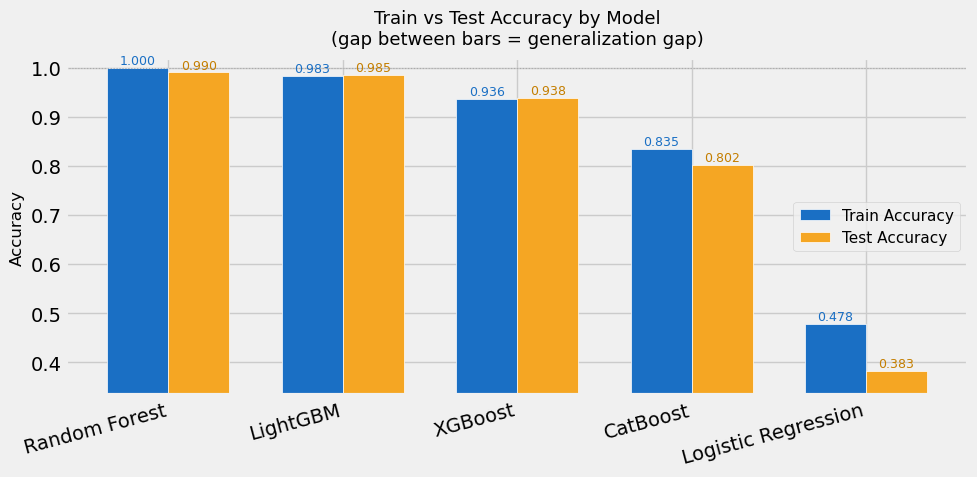

Reading guide:
  • Blue bar = how well the model learned the training data.
  • Orange bar = how well it predicts on NEW, unseen data — the honest score.
  • If blue >> orange, the model overfitted (memorised training data).
  • We want the orange bar to be as tall as possible.


In [41]:
# ── Chart: Model accuracy comparison ──────────────────────────────────────────
# This bar chart lets you visually compare train vs test accuracy for every model.
# A model where the blue bar is much taller than the orange bar is overfitting.

fig, ax = plt.subplots(figsize=(10, 5))
x       = range(len(comparison_df))
width   = 0.35

bars_train = ax.bar([i - width/2 for i in x], comparison_df['Train Accuracy'],
                    width, label='Train Accuracy', color='#1a6fc4', edgecolor='white')
bars_test  = ax.bar([i + width/2 for i in x], comparison_df['Test Accuracy'],
                    width, label='Test Accuracy',  color='#f5a623', edgecolor='white')

# Label each bar with its value
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#1a6fc4')
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#c47e00')

ax.set_xticks(list(x))
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.set_ylim(comparison_df['Test Accuracy'].min() - 0.05, 1.02)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Train vs Test Accuracy by Model\n(gap between bars = generalization gap)', fontsize=13, pad=10)
ax.legend(fontsize=11)
ax.axhline(1.0, color='#aaa', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Reading guide:")
print("  • Blue bar = how well the model learned the training data.")
print("  • Orange bar = how well it predicts on NEW, unseen data — the honest score.")
print("  • If blue >> orange, the model overfitted (memorised training data).")
print("  • We want the orange bar to be as tall as possible.")


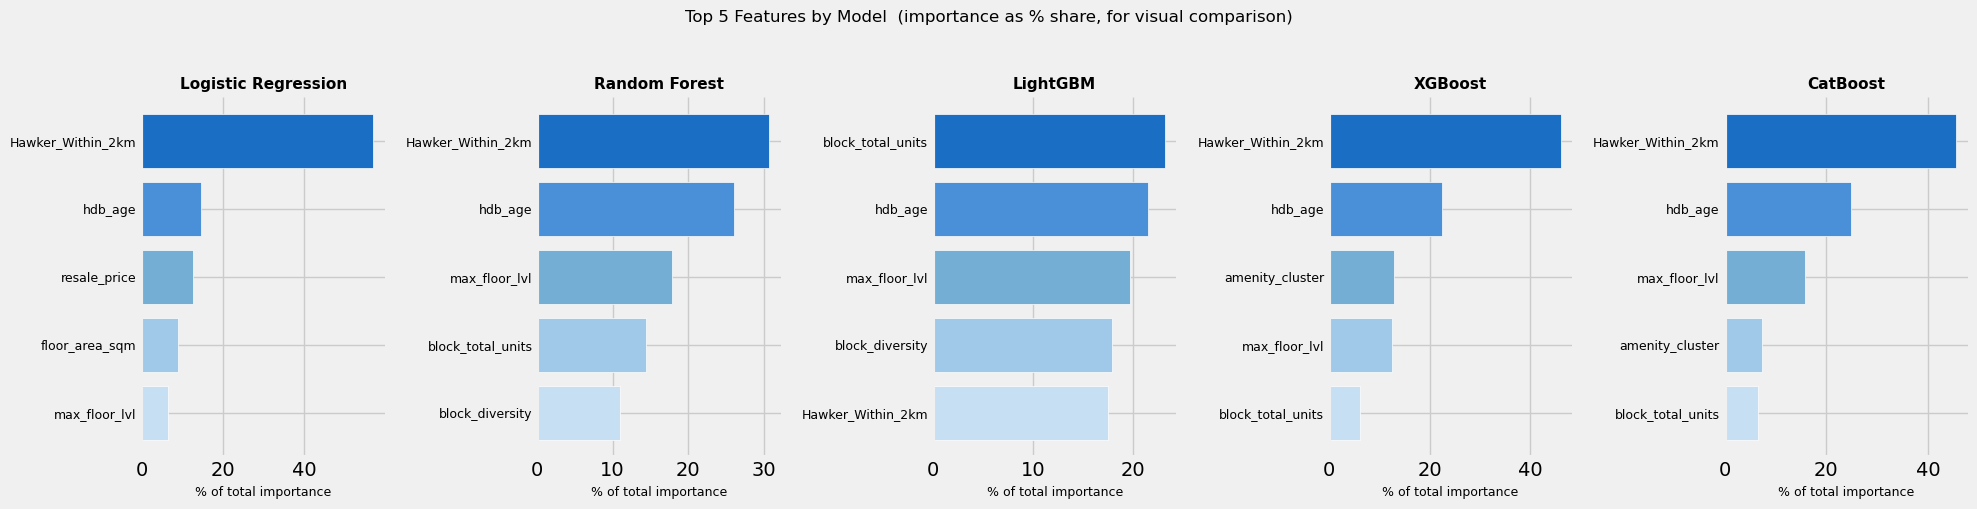

Reading guide:
  • Longer bar = feature contributes more to that model's decisions.
  • Features appearing in the top 5 across most models are the most universally important.
  • Differences between models show where each algorithm places its emphasis.


In [42]:
# ── Chart: Top features across all models ─────────────────────────────────────
# For each model, we take its top-5 features and plot importance scores side by side.
# Features that rank highly across MULTIPLE models are the most reliable predictors.

n_models = len(all_results)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 5), sharey=False)
if n_models == 1:
    axes = [axes]

for ax, res in zip(axes, all_results):
    fi = res['Feature Importance'].head(5).copy()
    if fi.empty:
        ax.set_visible(False)
        continue
    # Normalise importance to 0–100 for easier visual comparison across models
    fi['Pct'] = 100 * fi['Importance'] / fi['Importance'].sum()
    colors = ['#1a6fc4', '#4a90d9', '#74aed4', '#a0c8e8', '#c6dff2'][:len(fi)]
    ax.barh(fi['Feature'][::-1], fi['Pct'][::-1], color=colors[::-1], edgecolor='white')
    ax.set_title(res['Model'], fontsize=11, fontweight='bold')
    ax.set_xlabel('% of total importance', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

fig.suptitle('Top 5 Features by Model  (importance as % share, for visual comparison)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Reading guide:")
print("  • Longer bar = feature contributes more to that model's decisions.")
print("  • Features appearing in the top 5 across most models are the most universally important.")
print("  • Differences between models show where each algorithm places its emphasis.")


In [43]:
print("Top 5 Features by Model")
print("─" * 60)
for r in all_results:
    print(f"\n{r['Model']}")
    fi = r['Feature Importance']
    if fi.empty:
        print("  Feature importance not available for this model.")
    else:
        display_aligned_table(
            fi.head(5),
            format_map={'Importance': '{:.6f}'},
            left_cols=['Feature'], right_cols=['Importance']
        )


Top 5 Features by Model
────────────────────────────────────────────────────────────

Logistic Regression


Feature,Importance
Hawker_Within_2km,9.773864
hdb_age,2.509334
resale_price,2.156402
floor_area_sqm,1.554873
max_floor_lvl,1.137922



Random Forest


Feature,Importance
Hawker_Within_2km,0.244528
hdb_age,0.207511
max_floor_lvl,0.141781
block_total_units,0.114700
block_diversity,0.087219



LightGBM


Feature,Importance
block_total_units,39165.000000
hdb_age,36334.000000
max_floor_lvl,33307.000000
block_diversity,30291.000000
Hawker_Within_2km,29631.000000



XGBoost


Feature,Importance
Hawker_Within_2km,0.394021
hdb_age,0.192619
amenity_cluster,0.110132
max_floor_lvl,0.107743
block_total_units,0.052372



CatBoost


Feature,Importance
Hawker_Within_2km,40.884324
hdb_age,22.240745
max_floor_lvl,14.200193
amenity_cluster,6.525594
block_total_units,5.810716


---

## Conclusion

This notebook trained and compared four classification models on 270,619 HDB resale transactions to predict the `town` label for each flat.

### Selection methodology

Models were ranked by:
1. **Test accuracy** (primary) — how accurately each model predicts the town on unseen transactions.
2. **Generalization gap** (secondary) — a smaller gap means the model is less overfit.
3. **Runtime** (tiebreaker) — among models within 1% of the best accuracy, the faster model is preferred for production use.

### Final recommendation

The cell below prints the recommended model based on the results of the current run.


In [44]:
if 'recommended_model' not in globals():
    raise RuntimeError(
        "Run Step 13 (Model Comparison Summary) first to generate the recommendation variables."
    )

print("=" * 70)
print("FINAL MODEL RECOMMENDATION")
print("=" * 70)
print(
    f"  Recommended model  : {recommended_model}\n"
    f"  Test accuracy      : {recommended_test_acc:.4f}  ({recommended_test_acc*100:.2f}%)\n"
    f"  Generalization gap : {recommended_gap:+.4f}\n"
    f"  Training runtime   : {recommended_runtime:.1f}s"
)
print()

if abs(recommended_gap) <= 0.02:
    stability = "Excellent — the model generalises very well to unseen data."
elif abs(recommended_gap) <= 0.05:
    stability = "Acceptable — slight overfitting detected; monitor performance in production."
else:
    stability = "Caution — generalization gap is high; consider regularisation or more data."

print(f"  Stability assessment: {stability}")
print()
print("Next steps:")
print("  1. Uncomment the export cell below to save this model to app/models/.")
print("  2. Restart the web application to pick up the new model files.")
print("  3. Validate predictions on a sample of recent transactions before full deployment.")


FINAL MODEL RECOMMENDATION
  Recommended model  : LightGBM
  Test accuracy      : 0.9854  (98.54%)
  Generalization gap : -0.0025
  Training runtime   : 58.8s

  Stability assessment: Excellent — the model generalises very well to unseen data.

Next steps:
  1. Uncomment the export cell below to save this model to app/models/.
  2. Restart the web application to pick up the new model files.
  3. Validate predictions on a sample of recent transactions before full deployment.


---

## Model Export (Optional)

Once a production candidate is selected, uncomment and run the cell below to serialise the model and its supporting artefacts to disk.

The web application (`app/app.py`) reads these files at startup. Export must be re-run whenever the model is retrained.

**Files exported:**

| File | Contents |
|------|---------|
| `rf_classifier.joblib` | Trained Random Forest model (replace with recommended model if different) |
| `scaler_classifier.joblib` | Fitted `StandardScaler` — must match the scaler used during training |
| `town_classes.json` | Ordered list of town names — index 0 = class 0, etc. |


In [45]:
# ── Uncomment this entire block to export the model and artefacts ─────────────
# import joblib, json
# from pathlib import Path

# MODEL_DIR = Path("../app/models")
# MODEL_DIR.mkdir(parents=True, exist_ok=True)

# # Export the recommended model's fitted object
# # Replace `rf_results` below with the results dict of the recommended model
# joblib.dump(rf_results["fitted_model"], MODEL_DIR / "rf_classifier.joblib")
# print("Saved: rf_classifier.joblib")

# # Export the scaler — must be the same scaler that transformed training data
# joblib.dump(scaler, MODEL_DIR / "scaler_classifier.joblib")
# print("Saved: scaler_classifier.joblib")

# # Export town class labels (order must match the integer encoding)
# with open(MODEL_DIR / "town_classes.json", "w") as f:
#     json.dump(class_names, f, indent=2)
# print(f"Saved: town_classes.json ({len(class_names)} towns)")

# print("\nAll classification artefacts exported to app/models/")
